# Absorption and Diffusion

This part is meant to combine all our previous results for absorption, diffusion, and convection shown in the previous three notebooks. The goal is to solve for:

\begin{equation}
\left\{\begin{aligned}
    \partial_t\rho&= D(\Delta\rho)-\dot m_a(\rho, \rho_s) \\
    \partial_t\rho_s&=\dot m_a(\rho, \rho_s)
\end{aligned}\right.
\end{equation}
Where $\rho$ is the density at that point and $\rho_s$ is the saturation of the metal. $D$ is the diffusivity, and $\mathbf{v}$ the velocity ($\mathbf v=(v_x, v_y)$).

Under initial condition and boundary conditions are (since there is no coupling effects of saturation of the metal I am pretty sure we do not need boundary conditions there, but I'll look into this and phrase it more rigorous):

\begin{equation}
\left\{ \begin{aligned}
    \rho(\mathbf{x}, 0)  &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho_s(\mathbf{x},0) &= 0, &\forall \mathbf{x}\in \Omega,\\
    \rho(\mathbf{x}, t)  &= 1, &\forall \mathbf{x}\in\partial\Omega_1,\forall t\geq 0, \\
    \partial_\mathbf{n}\rho(\mathbf{x}, t)  &= 0, &\forall \mathbf{x}\in\partial\Omega_2,\forall t\geq 0. \\

\end{aligned}\right.
\end{equation}

where $\mathbf x = (x, y)$. the function for calculating adsorption is simplified into:

$$
\dot m(\rho, \rho_s) = k\rho(\rho_{sat}-\rho_s)
$$

We will be expanding $\rho^n$, $\rho_s^n$, and $\dot m^n$ (the values at their respective timesteps) into Lagrange polynomials:

\begin{equation*}
\begin{aligned}
\rho^n&=\sum{\rho^{n,i}\psi^i},\\
\rho_s^n&=\sum{\rho_s^{n,i}\psi^i},\\
\dot m^n&=\sum{\dot m^{n,i}\psi^i}.
\end{aligned}
\end{equation*}

we want to solve for $\rho$ and $\rho_s$, so our solution vector $\mathbf{u^n}$ becomes:

$$
\mathbf{u^n} = \begin{pmatrix}\rho^{n, 1} \\ \vdots \\ \rho^{n, N} \\ \rho_s^{n, 1} \\ \vdots \\ \rho_s^{n, N}
\end{pmatrix}
$$

We also define the vector $\mathbf{\dot{m}}$ by the coefficients of the absorption:

\begin{equation*}
\mathbf{\dot{m}}^n =\begin{pmatrix}
m^{n,1}\\ \vdots \\ m^{n,N}
\end{pmatrix},\\
\end{equation*}



if we discretize and apply IMEX methods (now a combination between implicit and explicit methods as discussed in the previous sections) we get:

$$
\big(M+K\Delta t\big)\mathbf{u}^{n+1}=M\big[ \mathbf u^n + \mathbf{\dot m}_h^n(\mathbf{u}^n)\Delta t\big]
$$

## Import Julia Packages 

In [1]:
using Ferrite, SparseArrays, WriteVTK, Plots

In [2]:
name = "absorption_diffusion_convection_2d";

# Stop time, time step
dt = .005;
T = 1.0;

k = 1.0;        # rate of absorption
rho_sat = 0.6;   # saturation density of metal

vx = 0.8;       # x-velocity for convection
vy = 1.0;       # y-velocity for convection
velocity = Vec((vx, vy));

D = 1.0;        # Diffusivity

In [3]:
# generates 20 gridpoints between 
grid = generate_grid(Quadrilateral, (80, 80), Vec((0.0, 0.0)), Vec((1.0, 1.0)));

# generate the same 
qr = QuadratureRule{RefQuadrilateral}(2);

ip_rho = Lagrange{RefQuadrilateral, 1}();
cellvalues_rho = CellValues(qr, ip_rho);

ip_rhos = Lagrange{RefQuadrilateral, 1}()
cellvalues_rhos = CellValues(qr, ip_rhos);

# degree of freedom handler, 
dh = DofHandler(grid)
add!(dh, :rho, ip_rho)
add!(dh, :rho_s, ip_rhos)
close!(dh);

In [4]:
# for now we have no constraints
ch = ConstraintHandler(dh)

#create left_slit
addfacetset!(
    grid,
    "left_slit",
    x -> abs(x[1]) < 1e-8 && 0.25 <= x[2] <= 0.75
)

dbc_left = Dirichlet(
    :rho,
    getfacetset(grid, "left_slit"),
    (x, t) -> 1.0
)

add!(ch, dbc_left)
close!(ch)
update!(ch, 0.0)

In [5]:
function doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh)
    assembler = start_assemble(M)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    # loop over all cells
    for cell in CellIterator(dh)
        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Me = zeros(ndofs_cell, ndofs_cell)

        # rho
        reinit!(cellvalues_rho, cell)
        for q in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q)
            for i in 1:n_basefuncs_rho
                psi_i = shape_value(cellvalues_rho, q, i)
                for j in 1:n_basefuncs_rho
                    psi_j = shape_value(cellvalues_rho, q, j)
                    # :rho DOFs are first in cell_dofs
                    Me[i, j] += psi_i * psi_j * dx
                end
            end
        end

        # rhos
        reinit!(cellvalues_rhos, cell)
        for q in 1:getnquadpoints(cellvalues_rhos)
            dx = getdetJdV(cellvalues_rhos, q)
            for i in 1:n_basefuncs_rhos
                psi_i = shape_value(cellvalues_rhos, q, i)
                for j in 1:n_basefuncs_rhos
                    psi_j = shape_value(cellvalues_rhos, q, j)
                    # :rho_s DOFs are after :rho in cell_dofs
                    offset = n_basefuncs_rho
                    Me[offset + i, offset + j] += psi_i * psi_j * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Me)
    end

    return M
end

doassemble_M! (generic function with 1 method)

In [ ]:
function doassemble_K!(
    K::SparseMatrixCSC, 
    cellvalues_rho::CellValues, 
    cellvalues_rhos::CellValues, 
    dh::DofHandler
    )

    assembler = start_assemble(K)

    # number of basis functions per field
    n_basefuncs_rho  = getnbasefunctions(cellvalues_rho)
    n_basefuncs_rhos = getnbasefunctions(cellvalues_rhos)

    for cell in CellIterator(dh)

        # get global DOFs for this cell
        cell_dofs = celldofs(cell)
        ndofs_cell = length(cell_dofs)
        Ke = zeros(ndofs_cell, ndofs_cell)

        # rho is the only important bit since rho_s does not diffuse
        reinit!(cellvalues_rho, cell)

        for q_point in 1:getnquadpoints(cellvalues_rho)
            dx = getdetJdV(cellvalues_rho, q_point)

            for i in 1:n_basefuncs_rho
                dpsi_i = shape_gradient(cellvalues_rho, q_point, i)

                for j in 1:n_basefuncs_rho
                    dpsi_j = shape_gradient(cellvalues_rho, q_point, j)
                    # D∫ (∇ψ^i) ⋅ (∇ψ^j) dx
                    Ke[i, j] += D * (dpsi_j ⋅ dpsi_i) * dx
                end
            end
        end

        assemble!(assembler, cell_dofs, Ke)
    end

    return K
end


doassemble_K! (generic function with 1 method)

In [7]:
M = allocate_matrix(dh);
K = allocate_matrix(dh);
M = doassemble_M!(M, cellvalues_rho, cellvalues_rhos, dh);
K = doassemble_K!(K, cellvalues_rho, cellvalues_rhos, dh);

A = M + dt .* K; # + Dt .*L + dt .* K

In [8]:
ndofs_total = ndofs(dh)
u_n = zeros(ndofs_total)


# block ordering: (rho_1, rho_s_1, rho_2, rho_s_2, ...)?? idk
# dh is your DofHandler

# below code sets all initial ρ to one and ρ_s to zero

# for cell in CellIterator(dh)
#     dofs = celldofs(cell)  # global DOFs for this cell

#     # number of DOFs per field in this cell
#     n_rho   = getnbasefunctions(cellvalues_rho)
#     n_rhos  = getnbasefunctions(cellvalues_rhos)

#     # assuming first n_rho are :rho, next n_rhos are :rho_s
#     u_n[dofs[1:n_rho]] .= 1.0       # gas density = 1 initially
#     u_n[dofs[n_rho+1:end]] .= 0.0   # solid initially empty
# end

apply!(u_n, ch)

rhsdata = get_rhs_data(ch, A);
apply!(A, ch);

In [9]:
rho_dofs  = Int[]
rhos_dofs = Int[]

for cell in CellIterator(dh)
    cdofs = celldofs(cell)

    append!(rho_dofs,  cdofs[dof_range(dh, :rho)])
    append!(rhos_dofs, cdofs[dof_range(dh, :rho_s)])
end

rho_dofs  = unique(rho_dofs);
rhos_dofs = unique(rhos_dofs);

In [10]:
rho_hist = zeros(length(dt:dt:T));
rhos_hist = zeros(length(dt:dt:T));

In [11]:
pvd = paraview_collection(joinpath(name, name))

VTKGridFile(joinpath(name, name), dh) do vtk
    write_solution(vtk, dh, u_n)
    pvd[0.0] = vtk
end

VTKGridFile for the closed file "absorption_diffusion_convection_2d\absorption_diffusion_convection_2d.vtu".

For standard formulation a fem source/sink term would be:

$$
A\mathbf{x}^{n+1} = M\mathbf{x}^n+\mathbf{b}^n
$$

if we follow the steps the weak form for $\mathbf{b}$ becomen element wise:

$$
b^{n,j} = \int \dot m (\mathbf{x}^n)\psi^j d\Omega
$$

Now a usefull assumption to cut computational time down is:

$$
\mathbf{\dot m}^n \approx \mathbf{\dot m}_h^n = \sum \dot m^{n,j} \psi^i
$$

Where

$$
m^{n,i} = k \rho^{n,i}(\rho_{sat}-\rho_s^{n,i})
$$

which gives:

\begin{equation*}
\begin{aligned}
b^{n, j} &= \int \dot m (\mathbf{x}^n)\psi^j d\Omega \\
&\approx \sum \int \dot m^{n,i} \psi^i \psi^j d\Omega\\
&= \sum \int \psi^i \psi^j d\Omega  \,\, \dot m^{n,i}\\
\mathbf{b}^n&= M\mathbf{\dot m}_h^n
\end{aligned}
\end{equation*}

In [ ]:
mdot = zeros(ndofs_total)

# finally the timeloop
for (step, t) in enumerate(dt:dt:T)
    
    #First of all, we need to update the Dirichlet boundary condition values.
    # does not really do anything since we do not yet apply bc's
    update!(ch, t)

    # CHECK: I think both below do the same thing, and we also initialize it globally
    mdot = zeros(ndofs_total)
    mdot .= 0.0

    for (i_rho, i_rhos) in zip(rho_dofs, rhos_dofs)
        md = k * u_n[i_rho] * (rho_sat - u_n[i_rhos])

        mdot[i_rhos] += md
        mdot[i_rho]  -= md
    end
    
    #Secondly, we compute the right-hand-side of the problem.
    # for cell in CellIterator(dh)
    #     cell_dofs = celldofs(cell)
    #     n_rho   = getnbasefunctions(cellvalues_rho)
    #     n_rhos  = getnbasefunctions(cellvalues_rhos)
    #     dofs_rho  = cell_dofs[1:n_rho]
    #     dofs_rhos = cell_dofs[n_rho+1:end]

    #     # local values
    #     rho_vals   = x_n[dofs_rho]
    #     rho_s_vals = x_n[dofs_rhos]

    #     # compute the absorption term drho_sdt per DOF
    #     for (i_rho, i_rhos) in zip(dofs_rho, dofs_rhos)
    #         # mdot
    #         dms = drho_sdt(x_n[i_rhos], x_n[i_rho], t)

    #         # add to CHANGE vector
    #         mdot[i_rhos] += 1.0/1600.0 #dms
    #         # gas is consumed, optional:
    #         mdot[i_rho]  -= 1.0/1600.0 #dms
    #     end
    # end

    b = M * u_n  + dt * (M * mdot)
    #Then, we can apply the boundary conditions of the current time step.
    apply_rhs!(rhsdata, b, ch)

    #Finally, we can solve the time step and save the solution afterwards.
    u = A \ b

    
    VTKGridFile(joinpath(name, "$(name)_1-$step"), dh) do vtk
        write_solution(vtk, dh, u)
        pvd[t] = vtk
    end
    #At the end of the time loop, we set the previous solution to the current one and go to the next time step.
    u_n .= u
    # keep this for plotting
    rho_hist[step] = u_n[1]
    rhos_hist[step] = u_n[5]

end

In [13]:
vtk_save(pvd);

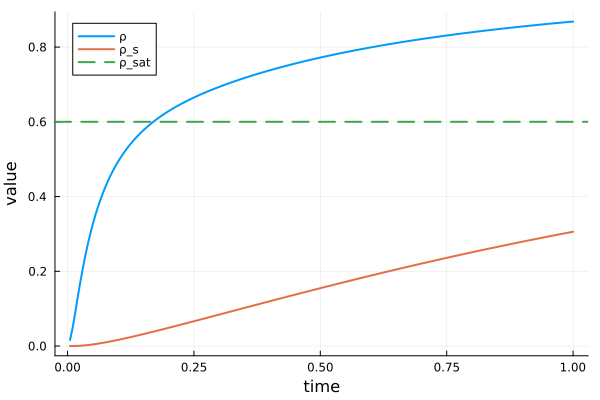

In [14]:
times = collect(dt:dt:T)

plot(times, rho_hist,
     xlabel = "time",
     ylabel = "value",
     label = "ρ",
     lw = 2)

plot!(times, rhos_hist,
      label = "ρ_s",
      lw = 2)


hline!([rho_sat],
       label = "ρ_sat",
       lw = 2,
       linestyle = :dash)